**Imports**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**Code**

*Here we made a variable called "df" and put inside of it the data wich is the ames housing data*

In [3]:
df = pd.read_csv("AmesHousing.csv")

*Printing the first 5 rows of data*

In [ ]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


**Here we get the shape of the data**, I refreshed my memory on how to get the shape of the csv from geeks for geeks (https://www.geeksforgeeks.org/python/python-pandas-df-size-df-shape-and-df-ndim/)

In [7]:
print(f"The shape of the data is : {df.shape}")

The shape of the data is : (2930, 82)


Here we get see if the data has anything wrong with it, e.g wrong data types in columns, and we are going to fix two rows and they are : MS SubClass and Sale Condition. They are both categorical columns but MS SubClass is an int64 (integer) and Sale Condition is an str (string)

In [14]:
df["MS SubClass"] = df["MS SubClass"].astype("object")
df["Sale Condition"] = df["Sale Condition"].astype("object")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   object 
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

Here we are finding the null values, I have chose two of the columns that need differnet approches which are "Pool QC" and "Garage Finish", first we are going to start with Pool QC and we are going to **drop** the column because nearly *99.5%* of the values are missng. Now the Garage finish column we are going to **fill in** the missing values because the missing values equals nearly *5%* of the values **(I have used here two sources and they are : ChatGPT and the course slides, they are cited below)**

In [47]:
df.isnull().sum()[df.isnull().sum() > 0] # The source is from ChatGPT, I used it because VSCode wouldn't show me all the columns at the have null values in them so I gave ChatGPT this prompt "How Do I See All Of The Columns That Have Nulls In Them?"
find_missing = ["N/A", "NA", "not reported", "Unknown", "?", 0] # This is from the course slides, slide number : 50
df_norm = df.copy() # This is from the course slides, slide number : 50
df_norm["Garage Finish"] = df_norm["Garage Finish"].replace(find_missing, np.nan) # This is from the course slides, slide number : 50
df_norm["Garage Finish"] = df_norm["Garage Finish"].fillna("None") # From the course slides, slide number : 50
df_norm = df_norm.drop("Pool QC", axis = 1) # This is from the course slides, slide number : 52
df = df_norm.copy()
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Screen Porch,Pool Area,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,0,NaN,NaN,0,5,2010,WD,Normal,215000.0
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,120,0,MnPrv,NaN,0,6,2010,WD,Normal,105000.0
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,0,NaN,Gar2,12500,6,2010,WD,Normal,172000.0
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,0,NaN,NaN,0,4,2010,WD,Normal,244000.0
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,0,MnPrv,NaN,0,3,2010,WD,Normal,189900.0


Here we are trying to find if there are any duplicate rows but we didn't find any so we dont have to do anything

In [10]:
df.duplicated().sum()

np.int64(0)

Here we are making a Boxplot to check if there are any outliers then we are going to cap them **(from course slides)**

Text(0.5, 1.0, 'Sale Price Distribution with Outliers')

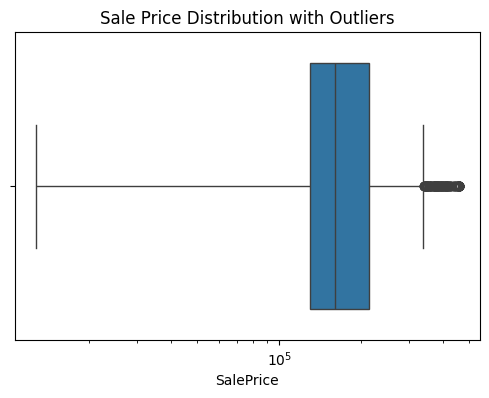

In [16]:
upper_limit = df["SalePrice"].quantile(0.99)
df["SalePrice"] = df["SalePrice"].clip(upper=upper_limit)
plt.figure(figsize=(6,4)); sns.boxplot(x=df["SalePrice"])
plt.xscale("log")
plt.title("Sale Price Distribution with Outliers")

Here we are making a clean_data() function so we can do all of the above in something we can reuse anywhere easily

The shape of the data is : (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Screen Porch,Pool Area,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,0,NaN,NaN,0,5,2010,WD,Normal,215000.0
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,120,0,MnPrv,NaN,0,6,2010,WD,Normal,105000.0
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,0,NaN,Gar2,12500,6,2010,WD,Normal,172000.0
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,0,NaN,NaN,0,4,2010,WD,Normal,244000.0
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,0,MnPrv,NaN,0,3,2010,WD,Normal,189900.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,0,GdPrv,NaN,0,3,2006,WD,Normal,142500.0
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,0,MnPrv,NaN,0,6,2006,WD,Normal,131000.0
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,0,MnPrv,Shed,700,7,2006,WD,Normal,132000.0
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,0,NaN,NaN,0,4,2006,WD,Normal,170000.0


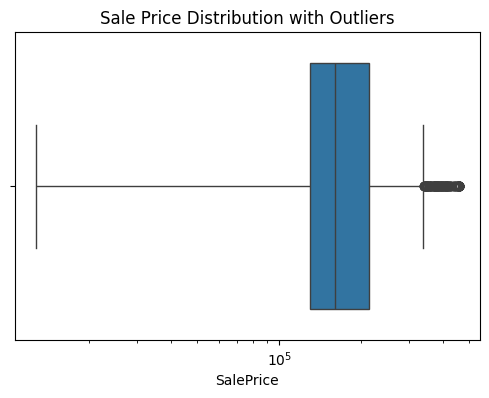

In [44]:
def clean_data(data):
    Raw_data = pd.read_csv(data)
    Raw_data.head()
    print(f"The shape of the data is : {Raw_data.shape}")
    Raw_data["MS SubClass"] = Raw_data["MS SubClass"].astype("object")
    Raw_data["Sale Condition"] = Raw_data["Sale Condition"].astype("object")
    Raw_data.isnull().sum()[Raw_data.isnull().sum() > 0]
    find_missing = ["N/A", "NA", "not reported", "Unknown", "?", 0]
    Raw_data_norm = Raw_data.copy()
    Raw_data_norm["Garage Finish"] = Raw_data_norm["Garage Finish"].replace(find_missing, np.nan)
    Raw_data_norm["Garage Finish"] = Raw_data_norm["Garage Finish"].fillna("None")
    Raw_data_norm = Raw_data_norm.drop("Pool QC", axis = 1)
    Raw_data = Raw_data_norm.copy()
    Raw_data.duplicated().sum()
    upper_limit = Raw_data["SalePrice"].quantile(0.99)
    Raw_data["SalePrice"] = Raw_data["SalePrice"].clip(upper=upper_limit)
    plt.figure(figsize=(6,4)); sns.boxplot(x=Raw_data["SalePrice"])
    plt.xscale("log")
    plt.title("Sale Price Distribution with Outliers")
    cleaned_data = Raw_data.copy()
    cleaned_data.to_csv("cleaned_data.csv", index=False) # From ChatGPT, I used it because I wanted to save the cleaned data to a new CSV file so I gave ChatGPT this prompt "how do I make the dataframe a csv and for it to save"
    assert cleaned_data["SalePrice"].isnull().sum() == 0, "SalePrice still has missing values"
    assert cleaned_data["Garage Finish"].isnull().sum() == 0, "Garage Finish still has missing values"
    assert (cleaned_data["SalePrice"] > 0).all(), "SalePrice contains zero or negative values"
    return cleaned_data

clean_data("AmesHousing.csv")

Here I added 3 Checks to see if I did everything right or not, these are also added to the clean_data() function **(Understood from ChatGPT)**

In [48]:
assert df["SalePrice"].isnull().sum() == 0, "SalePrice still has missing values"
assert df["Garage Finish"].isnull().sum() == 0, "Garage Finish still has missing values"
assert (df["SalePrice"] > 0).all(), "SalePrice contains zero or negative values"